# Análisis de `resultados_ap.csv`

Este cuaderno propone un análisis del comportamiento de los métodos `sa`, `qaoa` y `qaoa_warmstart` sobre el problema de asignación binario 0-1.

#### Hipótesis de trabajo

Dado que en las ejecuciones disponibles las soluciones finales suelen alcanzar el óptimo (`ratio_optimo = 1`, `brecha_optimo = 0`, `violacion = 0`), el valor comparativo principal está en:

- Diferencias en el tiempo total y su descomposición.
- Probabilidad de éxito y calidad media de las muestras.
- Estabilidad entre ejecuciones.
- Escalabilidad entre `2x2` y `3x3`.

##### Limitación en instancias 4x4

No se han podido analizar instancias de asignación de tamaño $4 \times 4$ porque el simulador necesita demasiada memoria. En el problema de asignación, una instancia $4 \times 4$ genera una variable binaria para cada posible asignación: $ 4 \cdot 4 = 16 $. Por tanto, el modelo tiene 16 variables binarias, por lo que el circuito necesita 16 qubits.

Al usar `StatevectorSampler`, que simula el estado cuántico completo, se guardan todas las combinaciones posibles de estos 16 qubits. Esto implica $ 2^{16} = 65\,536$ estados posibles.

Por lo tanto, durante la simulación, la matriz puede llegar a tener un tamaño de $ 65\,536 \times 65\,536 $, lo que requiere una cantidad de memoria muy superior a la disponible en el ordenador. Por eso, la ejecución falla antes de obtener resultados.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as fm

from scipy import stats
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

font_dir = Path("/Users/anabulchand/Downloads/cmu-serif")

for font_file in font_dir.glob("*.ttf"):
    fm.fontManager.addfont(str(font_file))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False
})

In [ ]:
df = pd.read_csv('resultados_ap.csv', na_values=['N/A'])

print('Dimensiones:', df.shape)
display(df.head())

In [4]:
tabla_ejecuciones = (
    df.groupby(["id", "metodo"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["qaoa", "qaoa_warmstart", "sa", "sqa"], fill_value=0)
)

tabla_ejecuciones["total"] = tabla_ejecuciones.sum(axis=1)

total = pd.DataFrame(
    [tabla_ejecuciones.sum()],
    index=["TOTAL"]
)

tabla_ejecuciones = pd.concat([tabla_ejecuciones, total])

display(tabla_ejecuciones)

metodo,qaoa,qaoa_warmstart,sa,sqa,total
201,5,5,5,5,20
202,5,5,5,5,20
203,5,5,5,5,20
204,5,5,5,5,20
301,5,5,5,5,20
302,5,5,5,5,20
303,5,5,5,5,20
304,5,5,5,5,20
401,0,0,5,5,10
402,0,0,5,5,10


In [ ]:
variables_resumen = [
    'ratio_optimo', 'brecha_optimo', 'exceso_peso', 'tiempo_total',
    'prob_optimo', 'ratio_optimo_medio', 't_solver',
    'prob_optimo_muestras', 'prob_optimo_starts', 'tasa_factibilidad',
    'ratio_medio_factibles', 'valor_medio_start', 'std_valor_start',
    'tiempo_medio_start'
]
variables_resumen = [c for c in variables_resumen if c in df.columns]

tabla_descriptivos = df.groupby('metodo')[variables_resumen].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(tabla_descriptivos) #Comparación estadística de cada método en las métricas de evaluación

### Análisis tiempo total de ejecución
#### Análisis tiempo de ejecución por método

Aquí se realiza un análisi de la distribución de los tiempos de ejecuión por método. Se representan primero de forma individual en tiempo de cada método. Esto es especialmente necesario para poder ver la distribución de `sa`, ya que presenta tiempos de ejecución significativamente menores y, de forma agregada, no es posible ver la distribución de este método. Posteriormente, se reliza una comparación de todos los métodos.

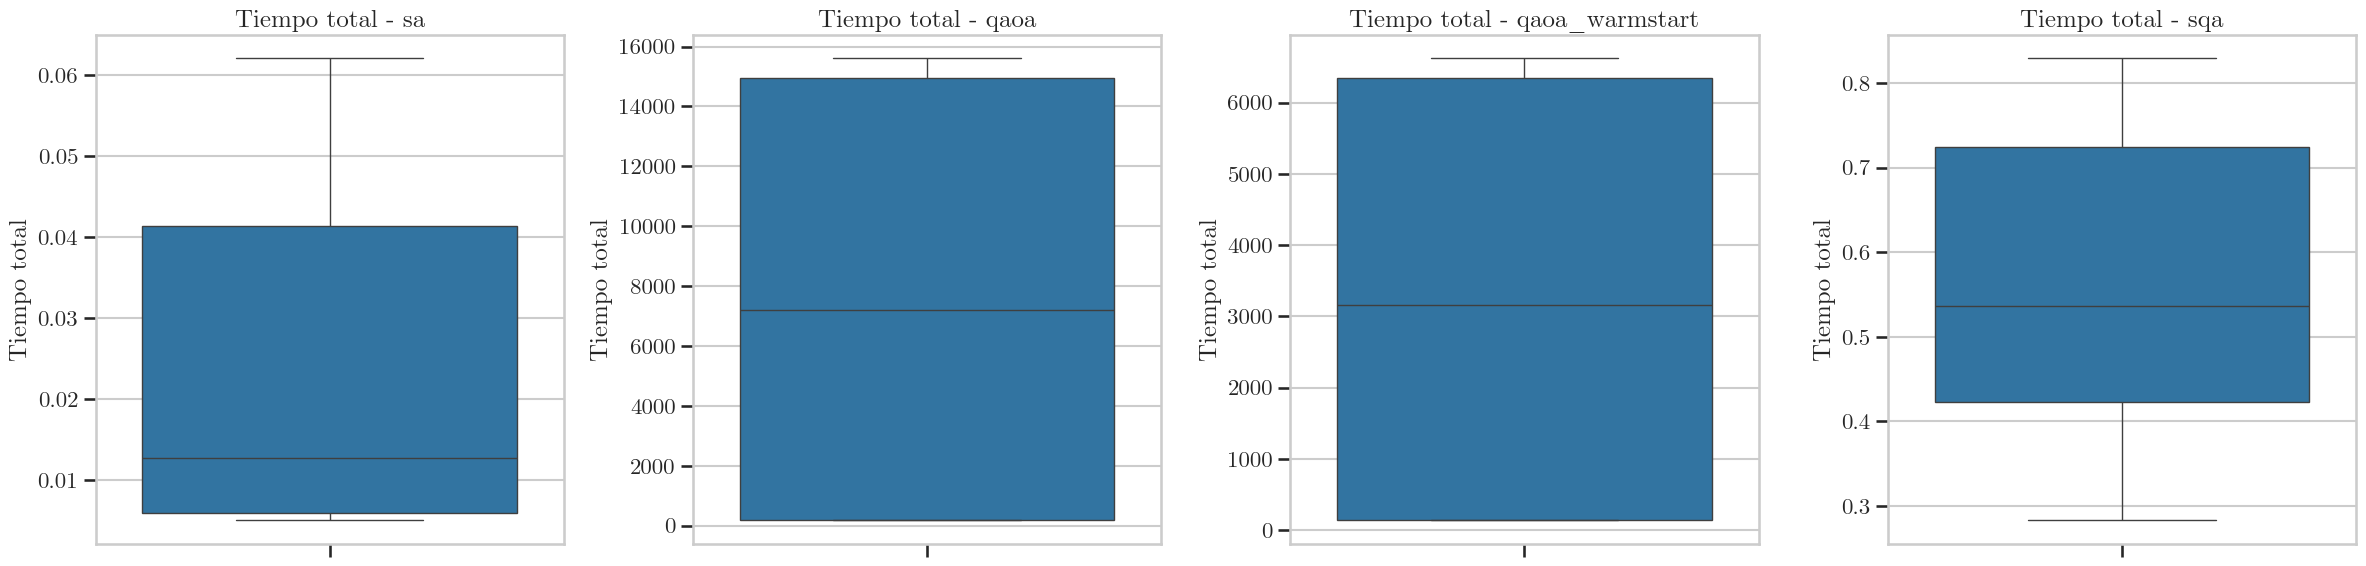

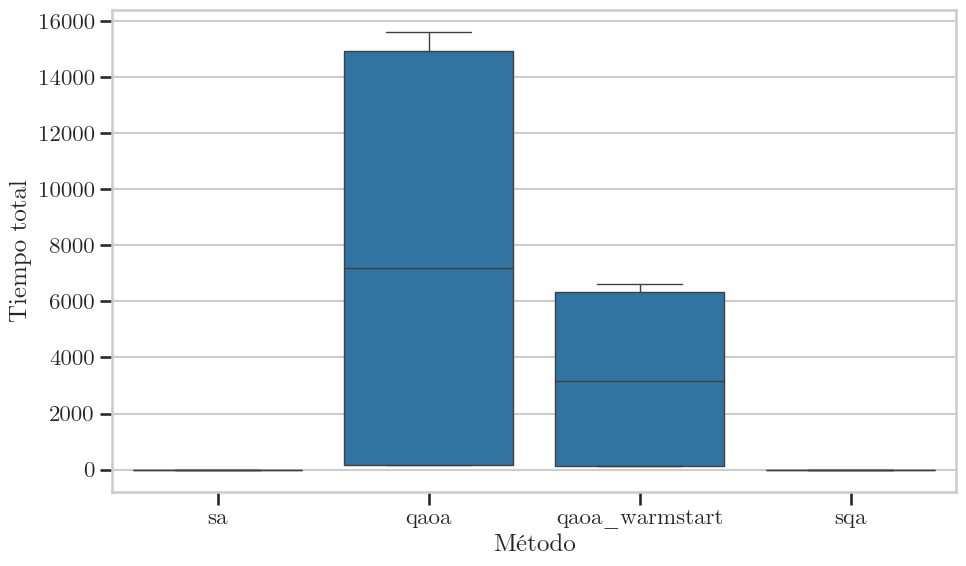

In [6]:
import os

# Crear carpeta si no existe
os.makedirs("figuras", exist_ok=True)

# Representación box-plot de cada método

metodos = df['metodo'].unique()

# ---- gráficas individuales ----
fig, axes = plt.subplots(1, len(metodos), figsize=(6 * len(metodos), 6))

if len(metodos) == 1:
    axes = [axes]

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df['metodo'] == metodo],
        y='tiempo_total',
        ax=axes[i],
        showfliers=True
    )
    axes[i].set_title(f'Tiempo total - {metodo}')
    axes[i].set_ylabel('Tiempo total')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_por_metodo_individual.png", dpi=300, bbox_inches="tight")
plt.show()


# Comparación agregada
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='metodo',
    y='tiempo_total',
    showfliers=True
)

plt.xlabel('Método')
plt.ylabel('Tiempo total')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_comparacion_metodos.png", dpi=300, bbox_inches="tight")
plt.show()

#### Análisis de escalabilidad con el tamaño del problema

En esta sección se realiza un análisis del comportamiento de los tiempos de ejecución a medida que aumenta el tamaño del problema. Para ello, se representa la mediana del tiempo total en función del número de ítems y del número de variables de la formulación QUBO. Este análisis, debido a las limitaciones en el tamaño de las instancias estudiadas, solo puede emplearse para observar cómo aumenta el tiempo cuando pasamos de instancias $2 \times 2$ a $3 \times 3$.

metodo,sa,sqa,qaoa,qaoa_warmstart
tamano_matriz,,,,
2x2,0.0057,0.6325,185.1032,147.5794
3x3,0.0128,0.6221,"14,856.6114","6,363.3202"
4x4,0.0438,0.4310,NaN,NaN


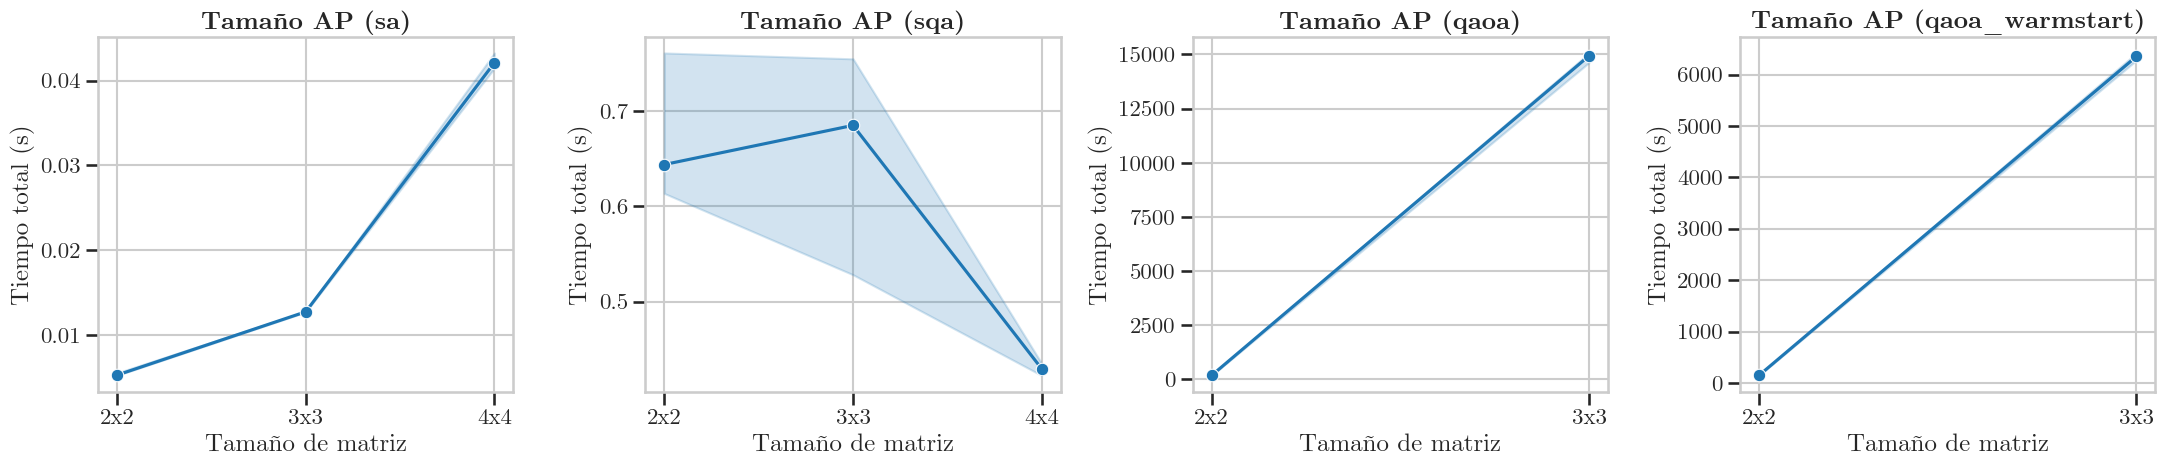

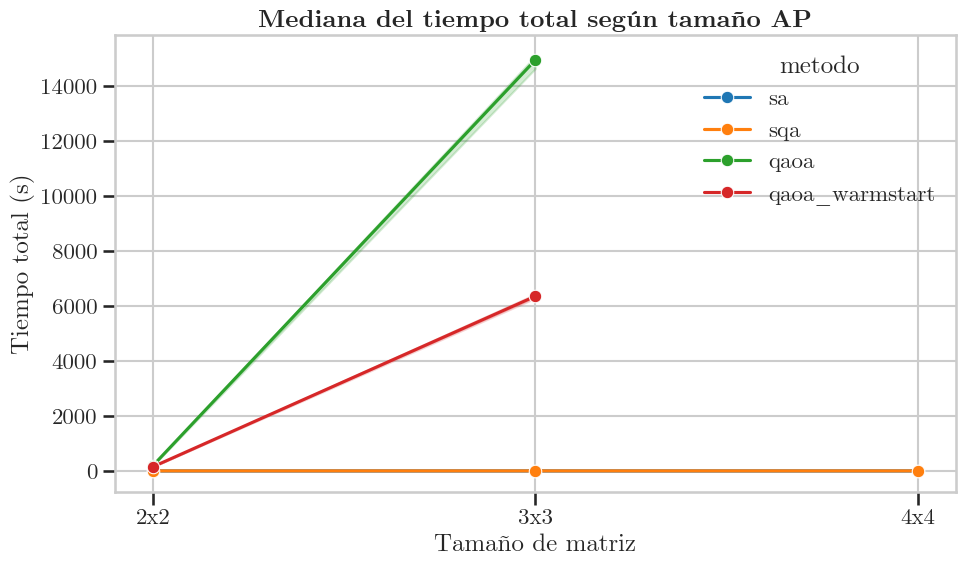

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Convertir columnas necesarias del nuevo formato AP
columnas_numericas = [
    "id",
    "optimo",
    "penalizacion",
    "coste_total",
    "violacion",
    "ratio_optimo",
    "tiempo_total"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Métodos en el orden deseado, incluyendo SQA
metodos = ["sa", "sqa", "qaoa", "qaoa_warmstart"]

# =========================
# TABLA TIEMPO MEDIO POR TAMAÑO DE MATRIZ
# =========================

tabla = (
    df
    .groupby(["tamano_matriz", "metodo"])["tiempo_total"]
    .mean()
    .unstack("metodo")
    .reindex(columns=metodos)
    .round(6)
)

display(tabla)

# =========================
# GRÁFICOS PARA CADA MÉTODO
# =========================

fig, axes = plt.subplots(1, len(metodos), figsize=(22, 5), sharey=False)

for i, metodo in enumerate(metodos):
    df_metodo = df[df["metodo"] == metodo].copy()

    sns.lineplot(
        data=df_metodo,
        x="tamano_matriz",
        y="tiempo_total",
        estimator="median",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Tamaño AP ({metodo})", fontweight="bold")
    axes[i].set_xlabel("Tamaño de matriz")
    axes[i].set_ylabel("Tiempo total (s)")

plt.tight_layout()
plt.show()

# =========================
# GRÁFICO AGREGADO
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="tamano_matriz",
    y="tiempo_total",
    hue="metodo",
    hue_order=metodos,
    estimator="median",
    marker="o"
)

plt.title(
    "Mediana del tiempo total según tamaño AP",
    fontweight="bold"
)
plt.xlabel("Tamaño de matriz")
plt.ylabel("Tiempo total (s)")
plt.tight_layout()
plt.show()


#### Análisis métricas internas específicas por familia de método

Aquí se realiza un análisis de métricas internas que son específicas de cada familia de métodos y que permiten complementar la comparación basada únicamente en tiempo de ejecución y calidad final de solución. En el caso de los métodos basados en QAOA, se analizan indicadores relacionados con la capacidad del algoritmo para alcanzar soluciones óptimas y con la calidad media de las soluciones generadas a lo largo del proceso. Para el método SA, se evalúan métricas asociadas al muestreo, como la probabilidad de obtener soluciones óptimas y la proporción de soluciones factibles generadas. Este análisis permite entender con mayor profundidad el comportamiento interno de cada enfoque y no solo su rendimiento observable final.

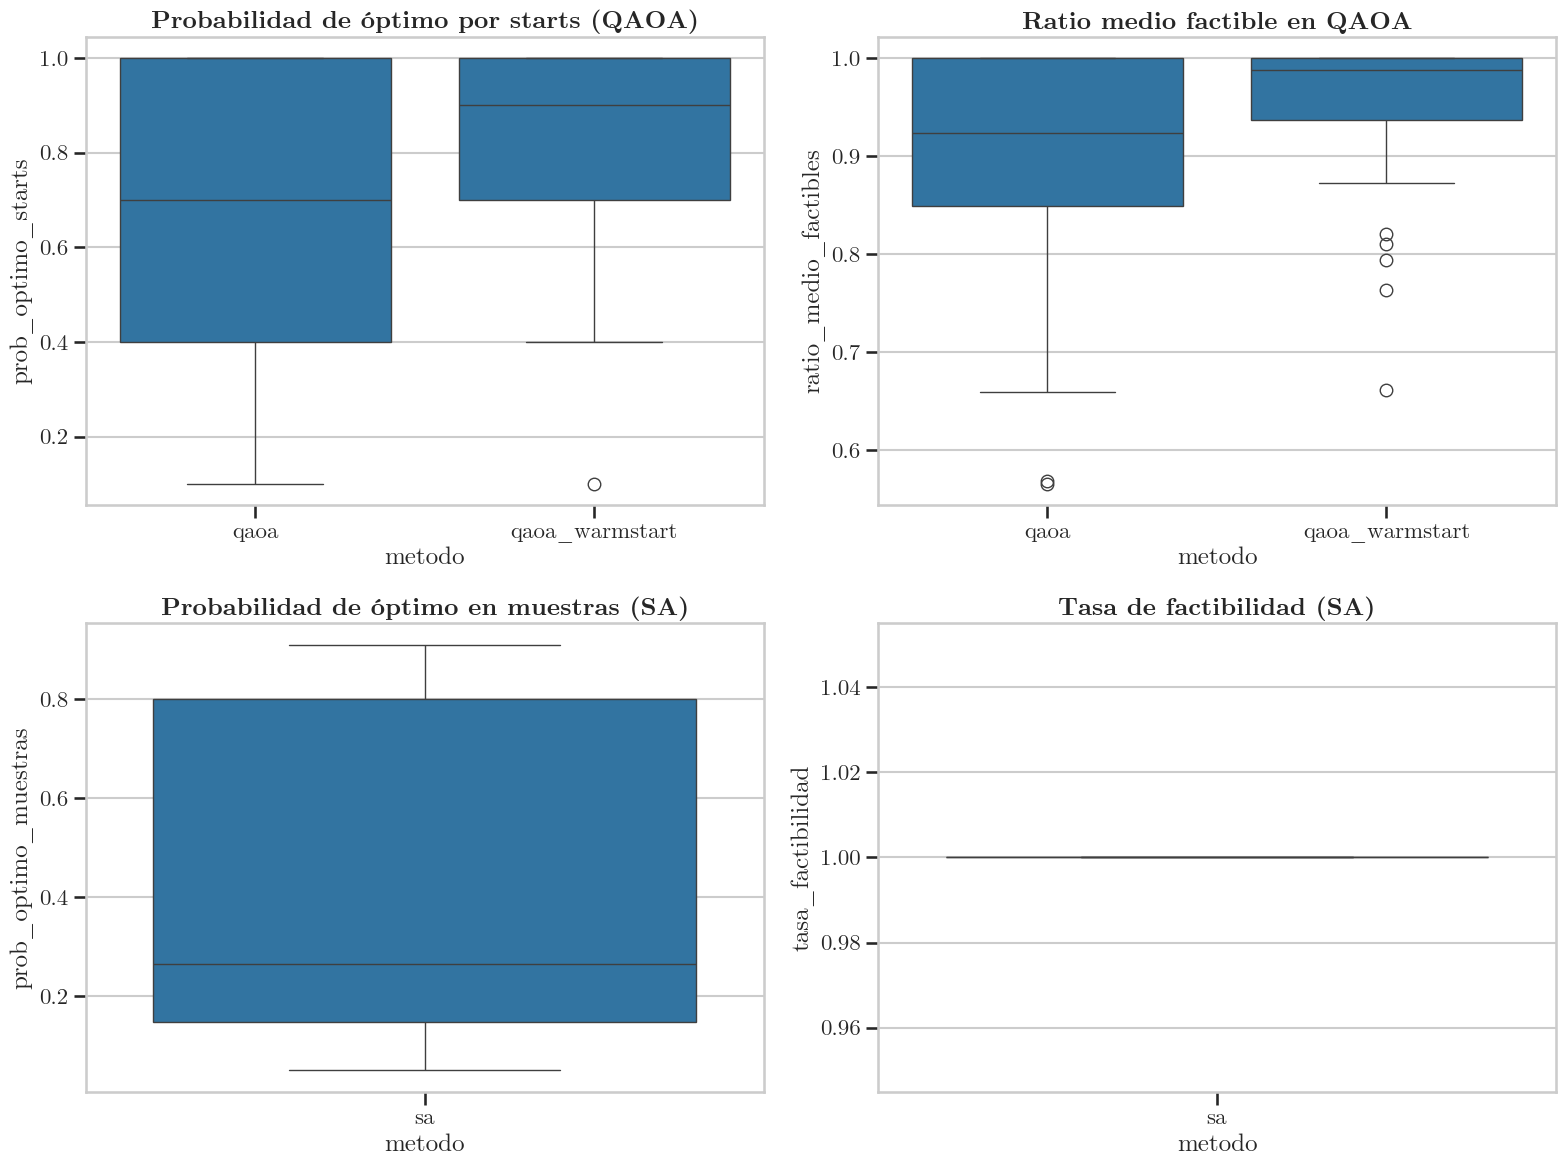

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Columnas del nuevo formato
columnas_numericas = [
    "prob_optimo_starts",
    "ratio_medio_factibles",
    "prob_optimo_muestras",
    "tasa_factibilidad"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Visualizacion 4: metricas internas especificas por familia de metodo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df_qaoa = df[df["metodo"].isin(["qaoa", "qaoa_warmstart"])].copy()
df_sa = df[df["metodo"] == "sa"].copy()

if df_qaoa["prob_optimo_starts"].notna().any():
    sns.boxplot(
        data=df_qaoa,
        x="metodo",
        y="prob_optimo_starts",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title(
        "Probabilidad de óptimo por starts (QAOA)",
        fontweight="bold"
    )
else:
    axes[0, 0].axis("off")

if df_qaoa["ratio_medio_factibles"].notna().any():
    sns.boxplot(
        data=df_qaoa,
        x="metodo",
        y="ratio_medio_factibles",
        ax=axes[0, 1]
    )
    axes[0, 1].set_title(
        "Ratio medio factible en QAOA",
        fontweight="bold"
    )
else:
    axes[0, 1].axis("off")

if df_sa["prob_optimo_muestras"].notna().any():
    sns.boxplot(
        data=df_sa,
        x="metodo",
        y="prob_optimo_muestras",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title(
        "Probabilidad de óptimo en muestras (SA)",
        fontweight="bold"
    )
else:
    axes[1, 0].axis("off")

if df_sa["tasa_factibilidad"].notna().any():
    sns.boxplot(
        data=df_sa,
        x="metodo",
        y="tasa_factibilidad",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title(
        "Tasa de factibilidad (SA)",
        fontweight="bold"
    )
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

En el caso de los enfoques basados en QAOA, tanto la probabilidad de alcanzar la solución óptima como el ratio óptimo medio presentan valores elevados y distribuciones muy similares entre QAOA estándar y QAOA *warm-start*. Esto sugiere que ambos métodos mantienen una capacidad comparable para encontrar soluciones de alta calidad, sin que la mejora temporal observada previamente en *warm-start* implique una ganancia significativa en calidad de solución. La principal diferencia entre ambos parece concentrarse en eficiencia computacional más que en rendimiento de optimización.

El análisis del ratio óptimo medio refuerza esta conclusión. Ambos métodos muestran medianas muy próximas a 1 y una dispersión reducida, lo que indica un comportamiento consistentemente cercano al óptimo incluso cuando no se alcanza la mejor solución exacta. La presencia de algunos valores atípicos más bajos evidencia cierta sensibilidad en determinadas ejecuciones, probablemente asociada a dificultades de convergencia o a variabilidad en el proceso de optimización paramétrica, pero estos casos no alteran el patrón general de alto rendimiento.

En el caso de SA, las métricas reflejan un comportamiento distinto. La probabilidad de encontrar la solución óptima dentro del conjunto de muestras es considerablemente más moderada y presenta una dispersión apreciable, lo que indica que el óptimo no aparece de forma dominante en el muestreo. Sin embargo, esto no implica necesariamente un peor rendimiento práctico, ya que SA ya había mostrado tiempos de ejecución muy inferiores y una alta estabilidad temporal. Es decir, aunque individualmente cada muestra tenga menor probabilidad de ser óptima, el bajo coste computacional del método permite compensar esta limitación mediante una exploración rápida y repetida del espacio de soluciones.

La tasa de factibilidad en SA se mantiene cercana a 1 en la mayoría de ejecuciones, lo que indica que el método genera predominantemente soluciones válidas y respeta de forma consistente las restricciones del problema. Aunque aparecen algunos valores atípicos con menor factibilidad, estos son minoritarios y no modifican el comportamiento general. 

En conjunto, los resultados muestran que mientras QAOA concentra su fortaleza en la calidad sistemática de las soluciones generadas, SA destaca por eficiencia y robustez operativa, manteniendo además un alto nivel de factibilidad.

## Contraste estadístico

In [9]:
import numpy as np
import pandas as pd
from scipy import stats

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Adaptado al nuevo formato AP
columnas_base = [
    "id",
    "tamano_matriz",
    "num_variables_qubo",
    "optimo",
    "penalizacion"
]

df["instancia_clave"] = df[columnas_base].astype(str).agg(" | ".join, axis=1)

columnas_numericas = [
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "ratio_medio_factibles",
    "tasa_factibilidad",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    std = diff.std(ddof=1)
    return diff.mean() / std if std != 0 else np.nan

def prueba_pareada(tabla, metodo_a, metodo_b, variable):
    x = tabla[metodo_a]
    y = tabla[metodo_b]
    diff = x - y

    shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan

    if pd.notna(shapiro_p) and shapiro_p > 0.05:
        test_name = "t-test apareado"
        pvalue = stats.ttest_rel(x, y).pvalue
    else:
        test_name = "Wilcoxon"
        pvalue = stats.wilcoxon(x, y).pvalue

    return {
        "variable": variable,
        "comparacion": f"{metodo_a} vs {metodo_b}",
        "n_pares": len(tabla),
        f"mediana_{metodo_a}": np.median(x),
        f"mediana_{metodo_b}": np.median(y),
        "shapiro_p_diferencias": shapiro_p,
        "prueba": test_name,
        "p_valor": pvalue,
        "cohens_d_paired": cohens_d_paired(x, y)
    }

comparables = df[df["metodo"].isin(["qaoa", "qaoa_warmstart", "sqa"])].copy()

agg = comparables.groupby(["instancia_clave", "metodo"], as_index=False).agg({
    "tiempo_total": "median",
    "prob_optimo_starts": "median",
    "prob_optimo_muestras": "median",
    "ratio_medio_factibles": "median",
    "tasa_factibilidad": "median",
})

resultados = []

# =========================
# Tiempo total: QAOA, Warmstart y SQA
# =========================

pivot_t = (
    agg.pivot(
        index="instancia_clave",
        columns="metodo",
        values="tiempo_total"
    )
    .dropna()
)

for metodo_a, metodo_b in [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]:
    tabla = pivot_t[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="tiempo_total"
            )
        )

# =========================
# Probabilidad de óptimo
# QAOA usa prob_optimo_starts
# SQA usa prob_optimo_muestras
# =========================

agg_prob = agg.copy()

agg_prob["prob_optimo_comparable"] = np.where(
    agg_prob["metodo"].isin(["qaoa", "qaoa_warmstart"]),
    agg_prob["prob_optimo_starts"],
    agg_prob["prob_optimo_muestras"]
)

pivot_p = (
    agg_prob.pivot(
        index="instancia_clave",
        columns="metodo",
        values="prob_optimo_comparable"
    )
    .dropna()
)

for metodo_a, metodo_b in [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]:
    tabla = pivot_p[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="prob_optimo_comparable"
            )
        )

display(pd.DataFrame(resultados))

,variable,comparacion,n_pares,mediana_qaoa,mediana_qaoa_warmstart,shapiro_p_diferencias,prueba,p_valor,cohens_d_paired,mediana_sqa
0,tiempo_total,qaoa vs qaoa_warmstart,8,"7,337.9791","3,208.4842",0.0022,Wilcoxon,0.0078,0.9423,NaN
1,tiempo_total,qaoa vs sqa,8,"7,337.9791",NaN,0.0015,Wilcoxon,0.0078,0.9585,0.6666
2,tiempo_total,qaoa_warmstart vs sqa,8,NaN,"3,208.4842",0.0011,Wilcoxon,0.0078,0.9796,0.6666
3,prob_optimo_comparable,qaoa vs qaoa_warmstart,8,0.6500,0.9000,0.0371,Wilcoxon,0.0625,-0.9192,NaN
4,prob_optimo_comparable,qaoa vs sqa,8,0.6500,NaN,0.0526,t-test apareado,0.0310,-0.9520,0.9500
5,prob_optimo_comparable,qaoa_warmstart vs sqa,8,NaN,0.9000,0.4158,t-test apareado,0.3807,-0.3307,0.9500


## Correlaciones entre complejidad y coste computacional

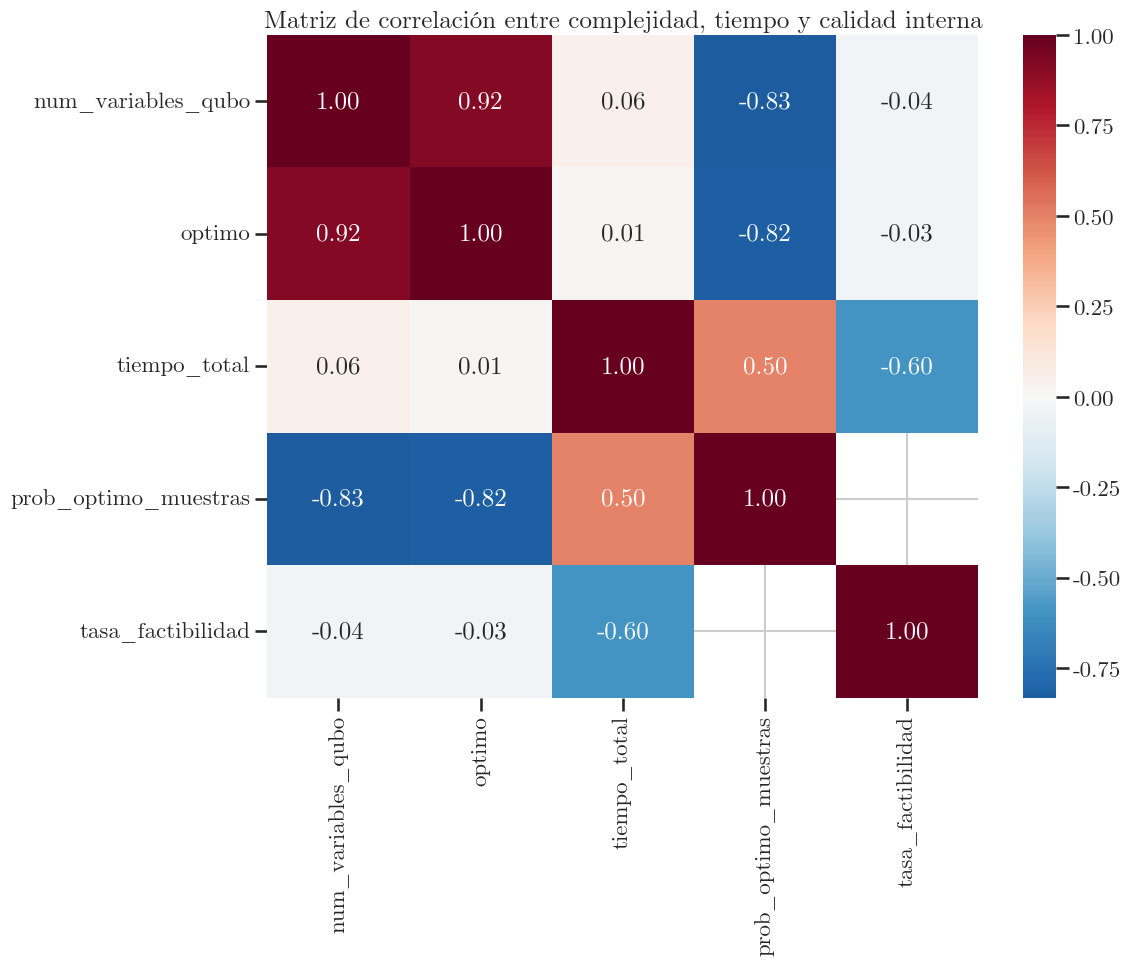

In [10]:
# Correlaciones entre complejidad y coste computacional
cols_corr = [
    'num_items', 'capacidad', 'num_variables_qubo', 'optimo',
    'tiempo_total', 't_solver',
    'prob_optimo', 'ratio_optimo_medio', 'prob_optimo_muestras',
    'tasa_factibilidad', 'valor_medio_start'
]
cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlación entre complejidad, tiempo y calidad interna')
plt.tight_layout()
plt.savefig("figuras/matriz_correlacion_complejidad_tiempo_calidad.png", dpi=300, bbox_inches="tight")
plt.show()

## Cálculo tiempo total de ejecución

In [12]:
df["tiempo_total"] = pd.to_numeric(df["tiempo_total"], errors="coerce")

tiempos_por_metodo = (
    df.groupby("metodo", as_index=False)
    .agg(
        num_ejecuciones=("tiempo_total", "count"),
        tiempo_total_segundos=("tiempo_total", "sum"),
    )
    .sort_values("tiempo_total_segundos", ascending=False)
)

tiempo_total_global = df["tiempo_total"].sum()

display(tiempos_por_metodo)

print(f"Tiempo total global: {tiempo_total_global:.4f} segundos")

,metodo,num_ejecuciones,tiempo_total_segundos
0,qaoa,40,"300,834.2917"
1,qaoa_warmstart,40,"130,217.9926"
3,sqa,60,33.7124
2,sa,60,1.2456


Tiempo total global: 431087.2424 segundos
Tiempo total global: 7184.7874 minutos
Tiempo total global: 119.7465 horas
